In [85]:
import pandas as pd

In [86]:
df = pd.read_csv("../data/florida_dental_markets.csv")
df

,City,Region,TargetCommuteMinutes,Population,PopulationGrowth,SeniorPopulationPercent,MedianHouseholdIncome,SafeArea2BRRent,DentistDensity,CompetitionScore,ImplantDemandScore,ProcedureFreedomScore,TechnologyScore,ProductionOpportunityScore,AdvancedGPIncomePotential,AdvancedGPOpportunityScore
0,Naples,Southwest Florida,30,197000,3.0,55.8,153182,2900,NaN,7,10,8,8,9,10,NaN
1,Boca Raton,South Florida,30,100000,1.5,24.6,106273,3000,NaN,8,9,7,9,8,9,NaN
2,Fort Myers,Southwest Florida,30,96000,2.5,23.2,63732,2300,NaN,5,8,8,7,8,8,NaN
3,Melbourne,Space Coast,30,87500,1.8,22.5,66991,2100,NaN,4,7,8,6,8,8,NaN
4,Orlando,Central Florida,30,320000,2.0,10.5,71000,2300,NaN,8,6,7,8,8,8,NaN
5,Tampa,Tampa Bay,30,405000,1.7,13.5,75000,2500,NaN,8,7,7,8,8,8,NaN
6,Jacksonville,Northeast Florida,30,985000,1.5,14.5,70000,2100,NaN,6,6,8,7,8,8,NaN
7,Gainesville,North Central Florida,30,146000,1.2,11.0,52000,1800,NaN,4,5,7,6,6,6,NaN
8,Port St. Lucie,Treasure Coast,30,240000,3.2,22.0,78000,2300,NaN,5,8,8,7,8,8,NaN
9,West Palm Beach,South Florida,30,125000,1.6,18.0,72000,2800,NaN,8,8,7,8,8,8,NaN


In [87]:
df["IncomeScore"] = (
    df["MedianHouseholdIncome"]
    / df["MedianHouseholdIncome"].max()
) * 10

df["SeniorScore"] = (
    df["SeniorPopulationPercent"]
    / df["SeniorPopulationPercent"].max()
) * 10

df["RentScore"] = (
    1
    - df["SafeArea2BRRent"]
    / df["SafeArea2BRRent"].max()
) * 10

df[[
    "City",
    "IncomeScore",
    "SeniorScore",
    "RentScore"
]]

,City,IncomeScore,SeniorScore,RentScore
0,Naples,10.000000,10.000000,0.645161
1,Boca Raton,6.937695,4.408602,0.322581
2,Fort Myers,4.160541,4.157706,2.580645
3,Melbourne,4.373295,4.032258,3.225806
4,Orlando,4.635009,1.881720,2.580645
5,Tampa,4.896137,2.419355,1.935484
6,Jacksonville,4.569728,2.598566,3.225806
7,Gainesville,3.394655,1.971326,4.193548
8,Port St. Lucie,5.091982,3.942652,2.580645
9,West Palm Beach,4.700291,3.225806,0.967742


In [88]:
df["IncomeScore"] = (
    df["MedianHouseholdIncome"]
    /
    df["MedianHouseholdIncome"].max()
) * 10

df["SeniorScore"] = (
    df["SeniorPopulationPercent"]
    /
    df["SeniorPopulationPercent"].max()
) * 10

df["GrowthScore"] = (
    df["PopulationGrowth"]
    /
    df["PopulationGrowth"].max()
) * 10

df["RentScore"] = (
    1 -
    (
        df["SafeArea2BRRent"]
        /
        df["SafeArea2BRRent"].max()
    )
) * 10

df[
[
    "City",
    "IncomeScore",
    "SeniorScore",
    "GrowthScore",
    "RentScore"
]]

,City,IncomeScore,SeniorScore,GrowthScore,RentScore
0,Naples,10.000000,10.000000,9.3750,0.645161
1,Boca Raton,6.937695,4.408602,4.6875,0.322581
2,Fort Myers,4.160541,4.157706,7.8125,2.580645
3,Melbourne,4.373295,4.032258,5.6250,3.225806
4,Orlando,4.635009,1.881720,6.2500,2.580645
5,Tampa,4.896137,2.419355,5.3125,1.935484
6,Jacksonville,4.569728,2.598566,4.6875,3.225806
7,Gainesville,3.394655,1.971326,3.7500,4.193548
8,Port St. Lucie,5.091982,3.942652,10.0000,2.580645
9,West Palm Beach,4.700291,3.225806,5.0000,0.967742


In [89]:
df["AdvancedGPOpportunityScore"] = (
    0.40 * df["IncomeScore"]
    +
    0.35 * df["SeniorScore"]
    +
    0.15 * df["GrowthScore"]
    +
    0.10 * df["RentScore"]
)

ranking = df[
    [
        "City",
        "AdvancedGPOpportunityScore"
    ]
].sort_values(
    by="AdvancedGPOpportunityScore",
    ascending=False
)

ranking

,City,AdvancedGPOpportunityScore
0,Naples,8.970766
8,Port St. Lucie,5.174786
1,Boca Raton,5.053472
10,Sarasota,4.938731
2,Fort Myers,4.549353
3,Melbourne,4.326939
11,Lakeland,4.291581
12,Clearwater,3.955631
13,St. Petersburg,3.901010
9,West Palm Beach,3.855923


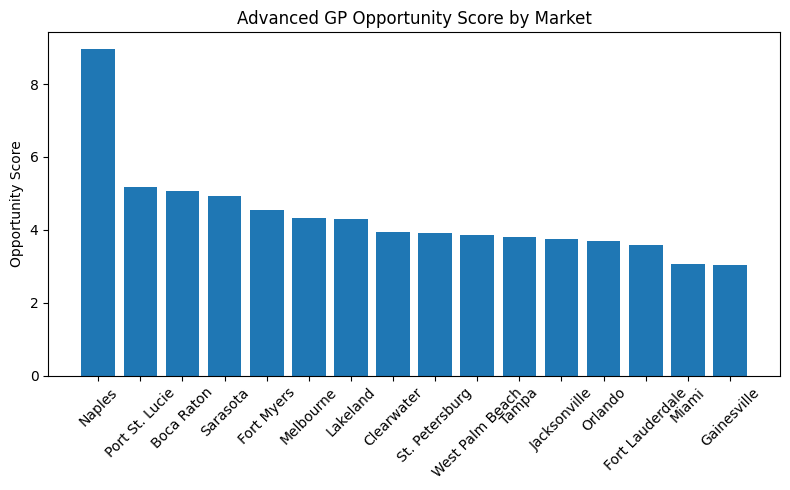

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ranking["City"],
    ranking["AdvancedGPOpportunityScore"]
)

plt.title(
    "Advanced GP Opportunity Score by Market"
)

plt.ylabel("Opportunity Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

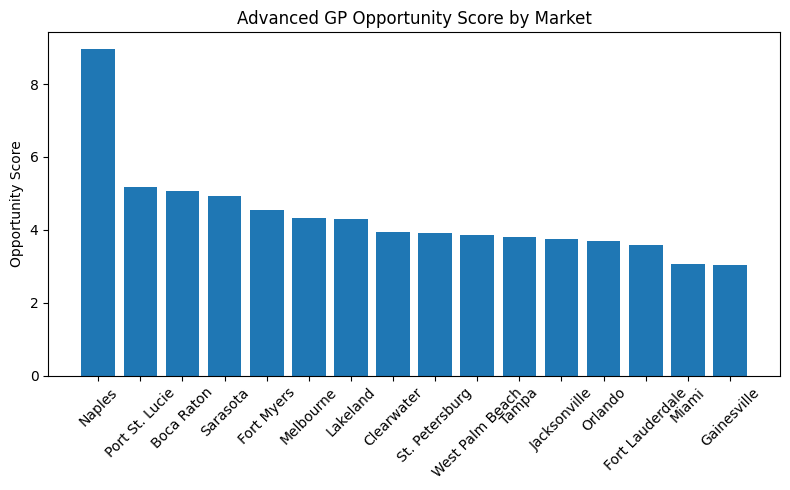

In [91]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking["City"],
    ranking["AdvancedGPOpportunityScore"]
)

plt.title(
    "Advanced GP Opportunity Score by Market"
)

plt.ylabel("Opportunity Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/advanced_gp_opportunity_score.png"
)

plt.show()

## Business Insight 1

Markets with stronger combinations of affluent patients and higher senior populations tend to achieve the highest Advanced GP Opportunity Scores.

This suggests that implant-focused dentists may benefit more from patient purchasing power and treatment acceptance than from population size alone.

In [92]:
df = pd.read_csv("../data/florida_dental_markets.csv")
df

,City,Region,TargetCommuteMinutes,Population,PopulationGrowth,SeniorPopulationPercent,MedianHouseholdIncome,SafeArea2BRRent,DentistDensity,CompetitionScore,ImplantDemandScore,ProcedureFreedomScore,TechnologyScore,ProductionOpportunityScore,AdvancedGPIncomePotential,AdvancedGPOpportunityScore
0,Naples,Southwest Florida,30,197000,3.0,55.8,153182,2900,NaN,7,10,8,8,9,10,NaN
1,Boca Raton,South Florida,30,100000,1.5,24.6,106273,3000,NaN,8,9,7,9,8,9,NaN
2,Fort Myers,Southwest Florida,30,96000,2.5,23.2,63732,2300,NaN,5,8,8,7,8,8,NaN
3,Melbourne,Space Coast,30,87500,1.8,22.5,66991,2100,NaN,4,7,8,6,8,8,NaN
4,Orlando,Central Florida,30,320000,2.0,10.5,71000,2300,NaN,8,6,7,8,8,8,NaN
5,Tampa,Tampa Bay,30,405000,1.7,13.5,75000,2500,NaN,8,7,7,8,8,8,NaN
6,Jacksonville,Northeast Florida,30,985000,1.5,14.5,70000,2100,NaN,6,6,8,7,8,8,NaN
7,Gainesville,North Central Florida,30,146000,1.2,11.0,52000,1800,NaN,4,5,7,6,6,6,NaN
8,Port St. Lucie,Treasure Coast,30,240000,3.2,22.0,78000,2300,NaN,5,8,8,7,8,8,NaN
9,West Palm Beach,South Florida,30,125000,1.6,18.0,72000,2800,NaN,8,8,7,8,8,8,NaN


In [93]:
df["IncomeScore"] = (
    df["MedianHouseholdIncome"] / df["MedianHouseholdIncome"].max()
) * 10

df["SeniorScore"] = (
    df["SeniorPopulationPercent"] / df["SeniorPopulationPercent"].max()
) * 10

df["GrowthScore"] = (
    df["PopulationGrowth"] / df["PopulationGrowth"].max()
) * 10

df["RentScore"] = (
    1 - df["SafeArea2BRRent"] / df["SafeArea2BRRent"].max()
) * 10

df["CompetitionAdjustedScore"] = (
    10 - df["CompetitionScore"]
)

df["AdvancedGPOpportunityScore"] = (
    0.20 * df["IncomeScore"] +
    0.20 * df["SeniorScore"] +
    0.10 * df["GrowthScore"] +
    0.15 * df["ImplantDemandScore"] +
    0.10 * df["ProcedureFreedomScore"] +
    0.10 * df["ProductionOpportunityScore"] +
    0.05 * df["TechnologyScore"] +
    0.05 * df["AdvancedGPIncomePotential"] +
    0.03 * df["CompetitionAdjustedScore"] +
    0.02 * df["RentScore"]
)

final_ranking = df[
    [
        "City",
        "AdvancedGPOpportunityScore",
        "ImplantDemandScore",
        "ProcedureFreedomScore",
        "ProductionOpportunityScore",
        "CompetitionScore"
    ]
].sort_values(
    by="AdvancedGPOpportunityScore",
    ascending=False
)

final_ranking

,City,AdvancedGPOpportunityScore,ImplantDemandScore,ProcedureFreedomScore,ProductionOpportunityScore,CompetitionScore
0,Naples,9.140403,10,8,9,7
10,Sarasota,6.700489,9,8,9,7
8,Port St. Lucie,6.558540,8,8,8,5
1,Boca Raton,6.554461,9,7,8,8
2,Fort Myers,6.196512,8,8,8,5
3,Melbourne,5.838127,7,8,8,4
9,West Palm Beach,5.664574,8,7,8,8
12,Clearwater,5.656048,8,7,8,6
14,Fort Lauderdale,5.542143,8,7,8,8
11,Lakeland,5.519994,6,8,7,4


## Business Insight 2

Markets with affluent patient populations and strong implant demand consistently outperform larger but less affluent markets.

For advanced implant-focused general dentists, treatment acceptance and patient purchasing power may be more important than population size alone.

In [94]:
implant_focused_ranking = (
    0.15 * df["IncomeScore"] +
    0.25 * df["SeniorScore"] +
    0.10 * df["GrowthScore"] +
    0.25 * df["ImplantDemandScore"] +
    0.10 * df["ProcedureFreedomScore"] +
    0.10 * df["ProductionOpportunityScore"] +
    0.05 * df["TechnologyScore"]
)

df["ImplantFocusedScore"] = implant_focused_ranking

df[
    [
        "City",
        "ImplantFocusedScore"
    ]
].sort_values(
    by="ImplantFocusedScore",
    ascending=False
)

,City,ImplantFocusedScore
0,Naples,9.537500
10,Sarasota,7.024528
1,Boca Raton,6.811555
8,Port St. Lucie,6.699460
2,Fort Myers,6.394758
9,West Palm Beach,5.911495
12,Clearwater,5.884059
3,Melbourne,5.876559
14,Fort Lauderdale,5.780027
13,St. Petersburg,5.598066


## Business Insight 3

Market selection alone does not determine long-term success.

For advanced implant-focused dentists, practice environment factors such as procedure freedom, implant volume, technology adoption, and treatment planning culture may significantly influence income potential.

In [95]:
df = pd.read_csv("../data/florida_dental_markets.csv")

df["IncomeScore"] = (
    df["MedianHouseholdIncome"] / df["MedianHouseholdIncome"].max()
) * 10

df["SeniorScore"] = (
    df["SeniorPopulationPercent"] / df["SeniorPopulationPercent"].max()
) * 10

df["GrowthScore"] = (
    df["PopulationGrowth"] / df["PopulationGrowth"].max()
) * 10

df["RentScore"] = (
    1 - df["SafeArea2BRRent"] / df["SafeArea2BRRent"].max()
) * 10

df["CompetitionAdjustedScore"] = 10 - df["CompetitionScore"]

df["AdvancedGPOpportunityScore"] = (
    0.20 * df["IncomeScore"] +
    0.20 * df["SeniorScore"] +
    0.10 * df["GrowthScore"] +
    0.15 * df["ImplantDemandScore"] +
    0.10 * df["ProcedureFreedomScore"] +
    0.10 * df["ProductionOpportunityScore"] +
    0.05 * df["TechnologyScore"] +
    0.05 * df["AdvancedGPIncomePotential"] +
    0.03 * df["CompetitionAdjustedScore"] +
    0.02 * df["RentScore"]
)

final_ranking = df[
    [
        "City",
        "Region",
        "AdvancedGPOpportunityScore",
        "MedianHouseholdIncome",
        "SeniorPopulationPercent",
        "ImplantDemandScore",
        "CompetitionScore",
        "SafeArea2BRRent"
    ]
].sort_values(
    by="AdvancedGPOpportunityScore",
    ascending=False
)

final_ranking

,City,Region,AdvancedGPOpportunityScore,MedianHouseholdIncome,SeniorPopulationPercent,ImplantDemandScore,CompetitionScore,SafeArea2BRRent
0,Naples,Southwest Florida,9.140403,153182,55.8,10,7,2900
10,Sarasota,Southwest Florida,6.700489,78000,28.0,9,7,2600
8,Port St. Lucie,Treasure Coast,6.558540,78000,22.0,8,5,2300
1,Boca Raton,South Florida,6.554461,106273,24.6,9,8,3000
2,Fort Myers,Southwest Florida,6.196512,63732,23.2,8,5,2300
3,Melbourne,Space Coast,5.838127,66991,22.5,7,4,2100
9,West Palm Beach,South Florida,5.664574,72000,18.0,8,8,2800
12,Clearwater,Tampa Bay,5.656048,66000,24.0,8,6,2300
14,Fort Lauderdale,South Florida,5.542143,74000,17.0,8,8,2900
11,Lakeland,Central Florida,5.519994,65000,18.0,6,4,1900


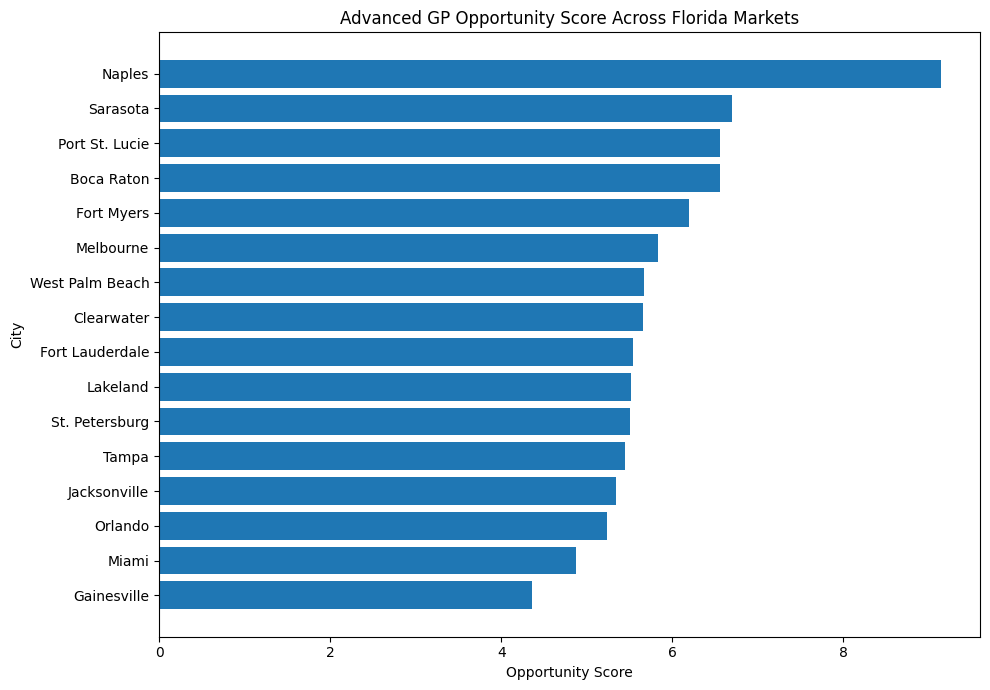

In [96]:
plt.figure(figsize=(10,7))

plt.barh(
    final_ranking["City"],
    final_ranking["AdvancedGPOpportunityScore"]
)

plt.title("Advanced GP Opportunity Score Across Florida Markets")
plt.xlabel("Opportunity Score")
plt.ylabel("City")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../charts/florida_advanced_gp_market_ranking.png")

plt.show()

In [97]:
practice_df = pd.read_csv(
    "../data/practice_environment_data.csv"
)

practice_df

,City,PracticeType,ImplantMentorship,CBCT,Scanner,FullArchOpportunity,TreatmentCoordinator,ProductionCultureScore
0,Naples,DSO,1,1,1,1,1,9
1,Naples,Private,1,1,1,1,1,10
2,Boca Raton,DSO,1,1,1,1,1,8
3,Fort Myers,DSO,1,1,1,1,1,8
4,Melbourne,DSO,1,1,0,0,1,7


In [98]:
import os

os.listdir("../data")

['gainesville_scenario.csv',
 'career_path_weights.csv',
 'practice_environment_data.csv',
 'florida_dental_markets.csv']

In [99]:
weights = pd.read_csv(
    "../data/career_path_weights.csv"
)

weights

,Scenario,IncomeWeight,SeniorWeight,GrowthWeight,ImplantWeight,TechnologyWeight
0,GP350,30,20,25,10,15
1,Implant500,20,20,10,35,15
2,FullArch700,15,25,5,40,15


## Final Recommendation

Based on the current model, Naples appears to provide the strongest environment for an advanced implant-focused GP pursuing $500,000+ annual income.

The combination of affluent patients, strong implant demand, and a large retiree population creates favorable conditions for high-value treatment acceptance.

Secondary markets include Sarasota and Boca Raton, which also demonstrate strong demographic and economic characteristics.

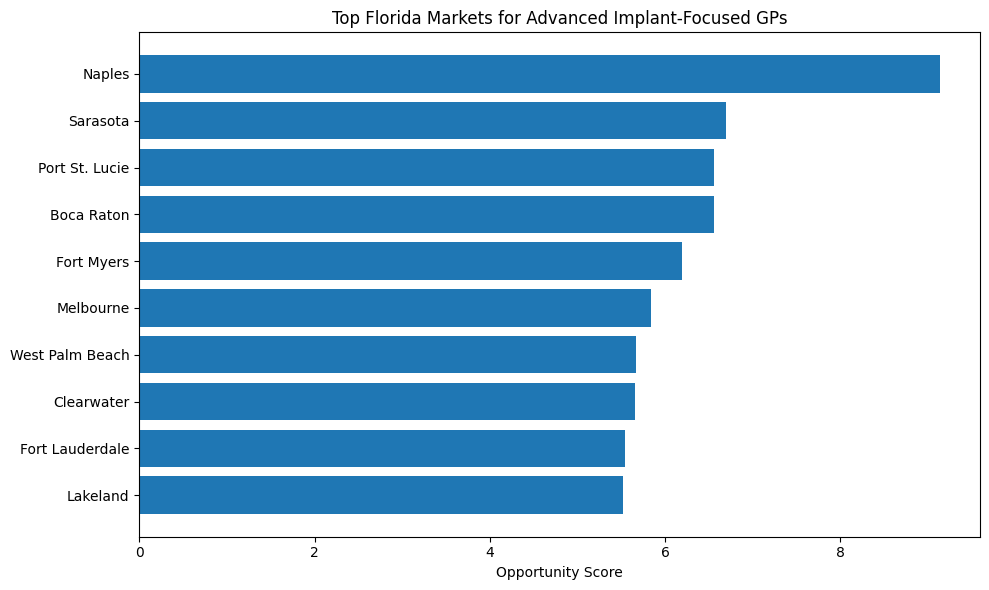

In [100]:
import matplotlib.pyplot as plt

top10 = final_ranking.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["City"],
    top10["AdvancedGPOpportunityScore"]
)

plt.title(
    "Top Florida Markets for Advanced Implant-Focused GPs"
)

plt.xlabel("Opportunity Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../charts/top_florida_gp_markets.png"
)

plt.show()

## Scenario Analysis: UF Student Strategy

This scenario evaluates dental markets within approximately 30 minutes of the University of Florida.

The objective is to identify locations that allow an advanced implant-focused GP to maximize production while maintaining reasonable commuting distance.

In [101]:
uf_df = pd.read_csv(
    "../data/gainesville_scenario.csv"
)

uf_df["UFScenarioScore"] = (
    0.40 * uf_df["IncomePotentialScore"]
    +
    0.30 * uf_df["ImplantOpportunityScore"]
    +
    0.20 * (10 - uf_df["CompetitionScore"])
    +
    0.10 * uf_df["LifestyleScore"]
)

uf_df.sort_values(
    by="UFScenarioScore",
    ascending=False
)

,Location,CommuteMinutes,CompetitionScore,ImplantOpportunityScore,IncomePotentialScore,LifestyleScore,UFScenarioScore
5,North Ocala,30,5,9,9,6,7.9
2,Newberry,25,3,8,8,8,7.8
1,Jonesville,20,4,8,8,8,7.6
3,Alachua,25,3,7,8,7,7.4
4,High Springs,30,2,7,7,7,7.2
0,Gainesville,10,6,6,6,9,5.9


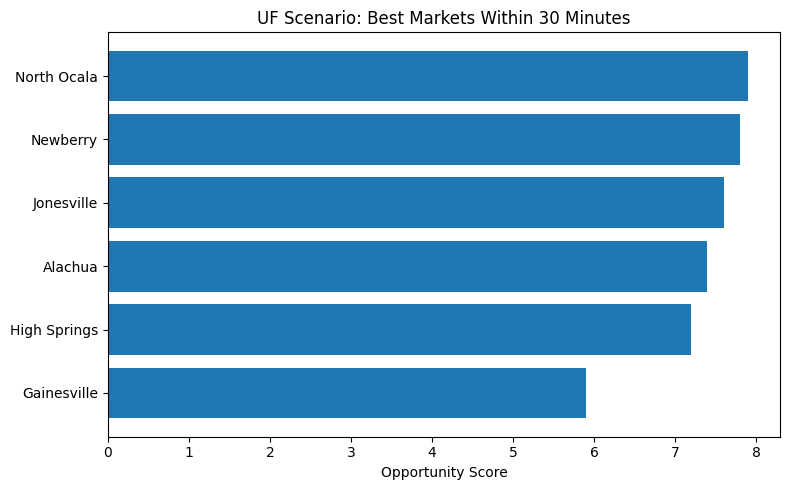

In [102]:
import matplotlib.pyplot as plt

ranking_uf = uf_df.sort_values(
    by="UFScenarioScore",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    ranking_uf["Location"],
    ranking_uf["UFScenarioScore"]
)

plt.title(
    "UF Scenario: Best Markets Within 30 Minutes"
)

plt.xlabel("Opportunity Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../charts/uf_scenario_ranking.png"
)

plt.show()

# Conclusion

This project developed a data-driven framework for evaluating Florida dental markets.

The analysis demonstrated that demographic quality, implant demand, and practice opportunity factors may be stronger predictors of advanced GP success than population size alone.

The framework provides a structured approach for career decision-making and can be extended using additional real-world data sources.